# Perturbation Sensitivity — Do Sinks Limit Information Spread?

**Replicating Barbero et al. Figure 2 for graphs.**

We perturb one node's features and measure how the perturbation propagates
through layers as a function of graph distance from the perturbed node.

Experiments:
1. PascalVOC: VNode vs no-VNode (strongest sinks, ~479 nodes)
2. ZINC: VNode vs no-VNode (smallest graphs, ~23 nodes)

If sinks limit over-mixing, perturbations should stay more localised with VNode.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import yaml
from tqdm import tqdm
from torch_geometric.utils import degree

from src.model import InstrumentedGPS
from src.datasets import get_dataloaders, DATASET_INFO

matplotlib.rcParams.update({
    'font.size': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

OUTPUTS_DIR = '../outputs'
FIGURES_DIR = '../outputs/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

/home/ec2-user/Geometric-Deep-Learning/Mini-Project/source/jupyter_notebook_venv/lib64/python3.9/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/ec2-user/Geometric-Deep-Learning/Mini-Project/source/jupyter_notebook_venv/lib/python3.9/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/ec2-user/Geometric-Deep-Learning/Mini-Project/source/jupyter_notebook_venv/lib64/python3.9/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/ec2-user/Geometric-Deep-Learning/Mini-Project/source/jupyter_notebook_venv/lib/python3.9/site-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/h

Device: cuda


In [2]:
def load_experiment(experiment_id, device):
    config_path = os.path.join(OUTPUTS_DIR, experiment_id, 'config.yaml')
    with open(config_path) as f:
        config = yaml.safe_load(f)
    dataset_info = DATASET_INFO[config['data']['dataset']].copy()
    if config['vnode']['enabled'] and dataset_info.get('num_node_types') is not None:
        dataset_info['num_node_types'] = config['vnode']['num_node_types']
        dataset_info['num_edge_types'] = config['vnode']['num_edge_types']
    model = InstrumentedGPS(config, dataset_info).to(device)
    model.load_state_dict(torch.load(
        os.path.join(OUTPUTS_DIR, experiment_id, 'best_model.pt'),
        map_location=device, weights_only=True
    ))
    model.eval()
    return model, config, dataset_info

## 1. Perturbation experiment

In [3]:
@torch.no_grad()
def run_perturbation_experiment(model, config, device, max_graphs=100, noise_scale=0.1):
    """Perturb one node, measure how it spreads across layers and graph distance."""
    _, _, test_loader, _ = get_dataloaders(config)
    model.eval()
    num_layers = model.num_layers
    spread = {l: {} for l in range(num_layers + 1)}
    
    graphs_done = 0
    for batch in tqdm(test_loader, desc='Perturbation'):
        if graphs_done >= max_graphs:
            break
        batch = batch.to(device)
        
        _ = model(batch, collect_diagnostics=True)
        clean_reps = {l: model.layer_data[l]['h'].clone() for l in range(num_layers + 1)}
        clean_batch_ids = model.layer_data[0]['batch']
        unique_graphs = clean_batch_ids.unique()
        
        for g_idx, g_id in enumerate(unique_graphs):
            if graphs_done >= max_graphs:
                break
            
            graph_mask = (clean_batch_ids == g_id)
            node_indices = torch.where(graph_mask)[0]
            num_nodes_g = len(node_indices)
            
            if num_nodes_g < 3:
                continue
            
            perturb_local = torch.randint(0, num_nodes_g, (1,)).item()
            perturb_global = node_indices[perturb_local].item()
            
            # BFS distances
            g_edges = batch.edge_index[:, batch.batch[batch.edge_index[0]] == g_id]
            local_map = {int(n): i for i, n in enumerate(node_indices)}
            adj = {i: set() for i in range(num_nodes_g)}
            for s, d in g_edges.t().tolist():
                if s in local_map and d in local_map:
                    adj[local_map[s]].add(local_map[d])
            
            distances = [-1] * num_nodes_g
            distances[perturb_local] = 0
            queue = [perturb_local]
            head = 0
            while head < len(queue):
                curr = queue[head]
                head += 1
                for nbr in adj[curr]:
                    if distances[nbr] == -1:
                        distances[nbr] = distances[curr] + 1
                        queue.append(nbr)
            
            # Perturb
            batch_perturbed = batch.clone()
            if batch_perturbed.x.dtype == torch.long:
                batch_perturbed.x[perturb_global] = torch.randint(
                    0, 28, batch_perturbed.x[perturb_global].shape,
                    device=batch_perturbed.x.device
                )
            else:
                noise = torch.randn_like(batch_perturbed.x[perturb_global:perturb_global+1].float()) * noise_scale
                batch_perturbed.x[perturb_global] = batch_perturbed.x[perturb_global].float() + noise.squeeze()
            
            _ = model(batch_perturbed, collect_diagnostics=True)
            perturbed_reps = {l: model.layer_data[l]['h'].clone() for l in range(num_layers + 1)}
            
            for l in range(num_layers + 1):
                clean_h = clean_reps[l][graph_mask]
                perturbed_h = perturbed_reps[l][graph_mask]
                delta = (clean_h - perturbed_h).float().norm(dim=-1)
                
                for node_i in range(num_nodes_g):
                    dist = distances[node_i]
                    if dist < 0:
                        continue
                    if dist not in spread[l]:
                        spread[l][dist] = []
                    spread[l][dist].append(delta[node_i].item())
            
            graphs_done += 1
    
    return spread

In [4]:
# Run perturbation for PascalVOC and ZINC (both VNode and no-VNode)
perturbation_results = {}

for eid in ['pascal-novnode', 'pascal-vnode', 'zinc-novnode', 'zinc-vnode']:
    print(f'\n=== {eid} ===')
    model, config, _ = load_experiment(eid, device)
    perturbation_results[eid] = run_perturbation_experiment(model, config, device, max_graphs=100)
    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    print(f'Done: {eid}')


=== pascal-novnode ===
  Loading cached PE for pascal_voc_sp/train from data/pe_cache/pascal_voc_sp_train_lappe16.pt
  Loading cached PE for pascal_voc_sp/val from data/pe_cache/pascal_voc_sp_val_lappe16.pt
  Loading cached PE for pascal_voc_sp/test from data/pe_cache/pascal_voc_sp_test_lappe16.pt


Perturbation:   9%|██████████████▍                                                                                                                                                    | 4/45 [00:05<01:00,  1.48s/it]


Done: pascal-novnode

=== pascal-vnode ===
  Loading cached PE for pascal_voc_sp/train from data/pe_cache/pascal_voc_sp_train_lappe16.pt
  Loading cached PE for pascal_voc_sp/val from data/pe_cache/pascal_voc_sp_val_lappe16.pt
  Loading cached PE for pascal_voc_sp/test from data/pe_cache/pascal_voc_sp_test_lappe16.pt


Perturbation:   9%|██████████████▍                                                                                                                                                    | 4/45 [00:06<01:03,  1.54s/it]


Done: pascal-vnode

=== zinc-novnode ===
  Loading cached PE for zinc/train from data/pe_cache/zinc_train_rwse28.pt
  Loading cached PE for zinc/val from data/pe_cache/zinc_val_rwse28.pt
  Loading cached PE for zinc/test from data/pe_cache/zinc_test_rwse28.pt


Perturbation:  12%|████████████████████▍                                                                                                                                              | 4/32 [00:01<00:11,  2.38it/s]


Done: zinc-novnode

=== zinc-vnode ===
  Loading cached PE for zinc/train from data/pe_cache/zinc_train_rwse28.pt
  Loading cached PE for zinc/val from data/pe_cache/zinc_val_rwse28.pt
  Loading cached PE for zinc/test from data/pe_cache/zinc_test_rwse28.pt


Perturbation:  12%|████████████████████▍                                                                                                                                              | 4/32 [00:01<00:11,  2.36it/s]

Done: zinc-vnode


## 2. Perturbation heatmaps

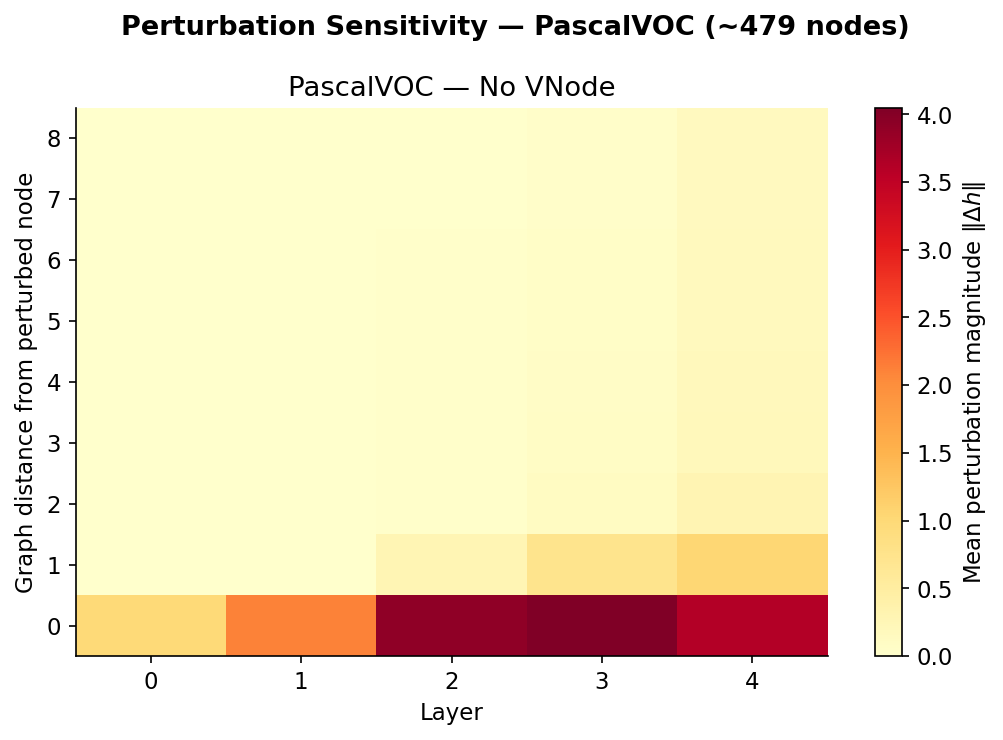

In [11]:
def spread_to_heatmap(spread, max_dist=8):
    num_layers = max(spread.keys()) + 1
    heatmap = np.zeros((num_layers, max_dist + 1))
    for l in range(num_layers):
        for d in range(max_dist + 1):
            values = spread[l].get(d, [])
            heatmap[l, d] = np.mean(values) if values else 0.0
    return heatmap


# PascalVOC heatmaps
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
max_dist_pascal = 8

hm_novn = spread_to_heatmap(perturbation_results['pascal-novnode'], max_dist_pascal)

im = ax.imshow(hm_novn.T, aspect='auto', origin='lower', cmap='YlOrRd', vmin=0, vmax=hm_novn.max())
ax.set_xlabel('Layer')
ax.set_ylabel('Graph distance from perturbed node')
ax.set_title('PascalVOC — No VNode')
ax.set_yticks(range(max_dist_pascal + 1))

plt.colorbar(im, ax=ax, label='Mean perturbation magnitude $\\|\\Delta h\\|$')
plt.suptitle('Perturbation Sensitivity — PascalVOC (~479 nodes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig10_perturbation_pascal.pdf'), bbox_inches='tight', dpi=150)
plt.show()

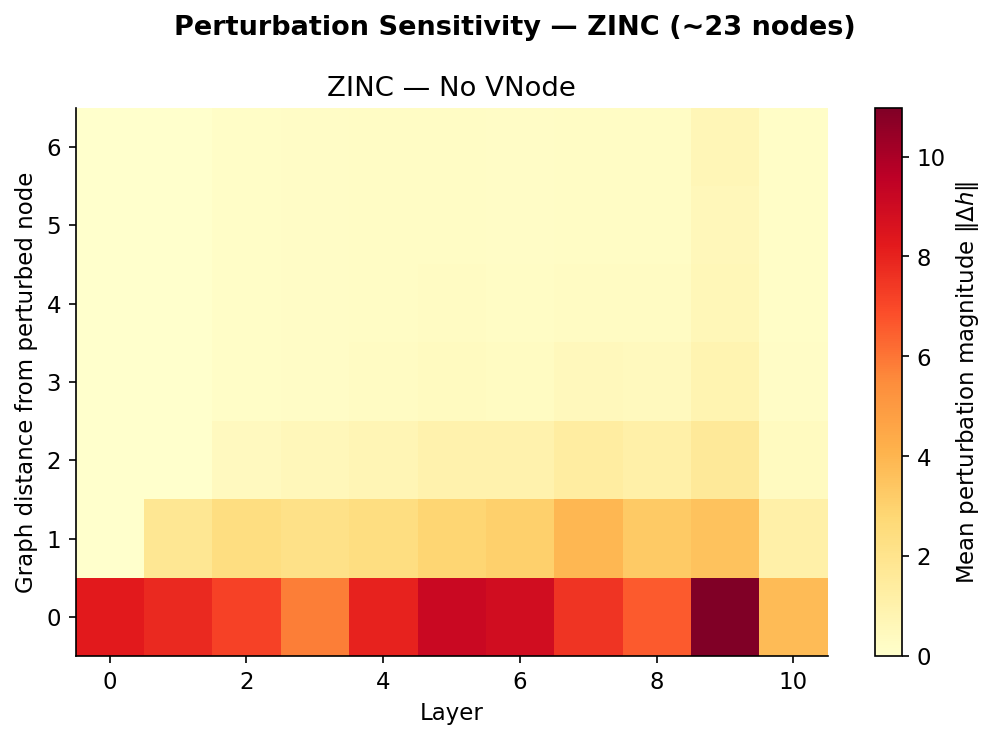

In [13]:
# ZINC heatmaps
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
max_dist_zinc = 6

hm_novn = spread_to_heatmap(perturbation_results['zinc-novnode'], max_dist_zinc)

im = ax.imshow(hm_novn.T, aspect='auto', origin='lower', cmap='YlOrRd', vmin=0, vmax=hm_novn.max())
ax.set_xlabel('Layer')
ax.set_ylabel('Graph distance from perturbed node')
ax.set_title('ZINC — No VNode')
ax.set_yticks(range(max_dist_zinc + 1))

plt.colorbar(im, ax=ax, label='Mean perturbation magnitude $\\|\\Delta h\\|$')
plt.suptitle('Perturbation Sensitivity — ZINC (~23 nodes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig10_perturbation_zinc.pdf'), bbox_inches='tight', dpi=150)
plt.show()

## 3. Perturbation spread by distance — line plots

Cleaner view: for each distance bucket (0, 1, 2, 3+), plot the mean perturbation
magnitude across layers.

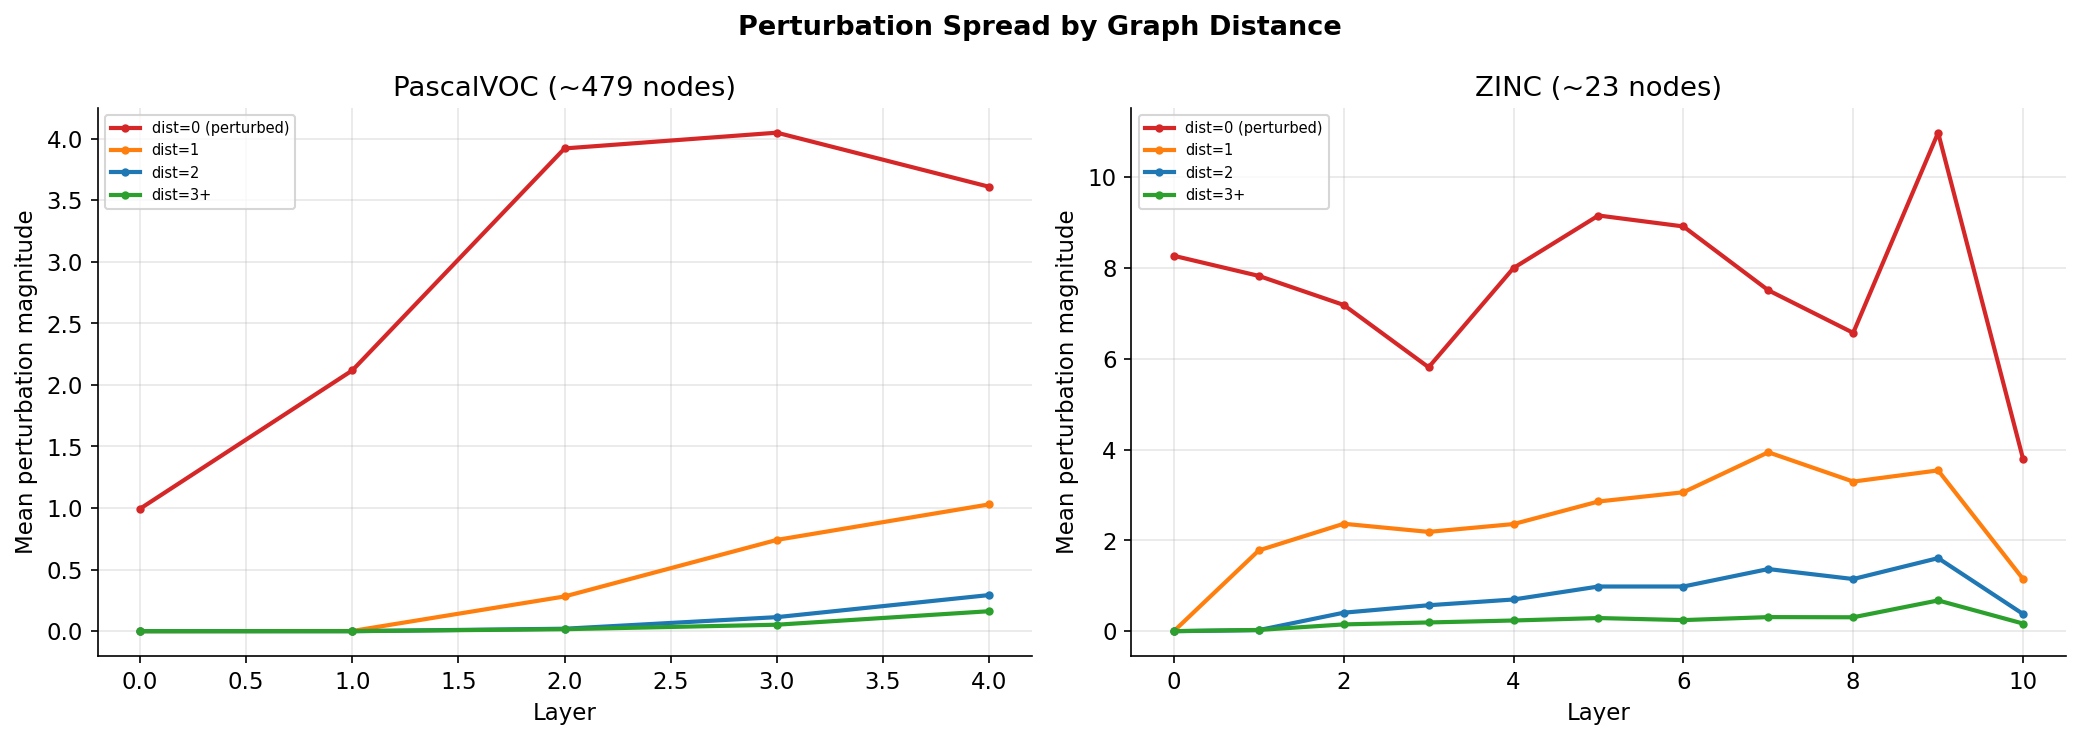

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets_pairs = [
    (axes[0], 'pascal', 'PascalVOC (~479 nodes)', 8),
    (axes[1], 'zinc', 'ZINC (~23 nodes)', 6),
]

dist_colors = [(0, 'tab:red', 'dist=0 (perturbed)'), (1, 'tab:orange', 'dist=1'),
               (2, 'tab:blue', 'dist=2'), (3, 'tab:green', 'dist=3+')]

for ax, ds_prefix, title, max_d in datasets_pairs:
    eid = f'{ds_prefix}-novnode'
    if eid not in perturbation_results:
        continue
    spread = perturbation_results[eid]
    num_layers = max(spread.keys()) + 1

    for dist, color, label in dist_colors:
        values = []
        for l in range(num_layers):
            if dist < 3:
                vals = spread[l].get(dist, [])
            else:
                vals = []
                for d in range(3, max_d + 1):
                    vals.extend(spread[l].get(d, []))
            values.append(np.mean(vals) if vals else 0.0)
        ax.plot(range(num_layers), values, color=color, linewidth=2, linestyle='-',
                marker='o', markersize=3, label=label)

    ax.set_xlabel('Layer')
    ax.set_ylabel('Mean perturbation magnitude')
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Perturbation Spread by Graph Distance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig11_perturbation_by_distance.pdf'), bbox_inches='tight', dpi=150)
plt.show()

## 4. Quantitative comparison: perturbation containment

Compute the ratio of perturbation at distance 0 vs distance 3+
at the last layer. Higher ratio = better containment.

In [16]:
print(f"{'Experiment':<22} {'d=0 (last L)':>14} {'d=3+ (last L)':>14} {'Ratio':>8}")
print('=' * 65)

for eid, spread in perturbation_results.items():
    num_layers = max(spread.keys())
    d0_vals = spread[num_layers].get(0, [0])
    d3_vals = []
    for d in range(3, 10):
        d3_vals.extend(spread[num_layers].get(d, []))
    
    d0_mean = np.mean(d0_vals)
    d3_mean = np.mean(d3_vals) if d3_vals else 0.0
    ratio = d0_mean / d3_mean if d3_mean > 1e-8 else float('inf')
    
    print(f'{eid:<22} {d0_mean:>14.4f} {d3_mean:>14.4f} {ratio:>8.2f}')

print('\nHigher ratio = perturbation stays more localised (less over-mixing)')

Experiment               d=0 (last L)  d=3+ (last L)    Ratio
pascal-novnode                 3.6088         0.1573    22.94
pascal-vnode                   3.8970         0.0000      inf
zinc-novnode                   3.7952         0.1701    22.31
zinc-vnode                     4.6161         0.0000      inf

Higher ratio = perturbation stays more localised (less over-mixing)


## 5. Summary

Key findings:
1. **Perturbation spread vs graph distance:** Does it decrease with distance?
2. **VNode effect:** Does VNode limit perturbation spread (like BOS in LLMs)?
3. **Dataset size effect:** Is containment stronger in larger graphs?